**MT - Assignment (Part 1)** <br>
B. Mahendar (20MCME25) and S. Anusri (20MCME31)<br>
Corpus chosen: English-Hindi<br>

In [1]:
import math
import matplotlib.pyplot as plt
import statistics
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import tensorflow as tf
from tensorflow import keras
import re

 **Open Files** <br>
Opening the files in the read mode

In [2]:
file1 = open("eng-hin-sample.en","r",encoding="utf-8")
file2 = open("eng-hin-sample.hi","r",encoding="utf-8")

In [3]:
#Check whether you can read the file or not
print(file1.read(100))
print(file2.read(100))
file1.seek(0)
file2.seek(0)

Two ambulances will be provided in each of these places.
New Zealand won two matches and lost once e
इसके लिए प्रत्येक थाने में दो-दो गाडि़यां उपलब्ध कराई जाएंगी।
न्यूजीलैंड को पाकिस्तान और आस्ट्रेलिया


0

# **Operations on Characters** #
Analysis of characters in the parallel corpus.

## **Calculate frequency of characters** ##
First create dictionaries to store the character vs count data.

Let us find the characters used and their count.

In [4]:
en_char_dict = dict()
hi_char_dict = dict()

### **English corpus** ###
Iterate through file and add each unique word to **en_char_dict** dictionary as key and the frequency of the word as value.

In [5]:
for x in file1:
  for character in x:
    if character in en_char_dict:
      en_char_dict[str(character)] += 1
    else :
      en_char_dict[str(character)] = 1
file1.seek(0)

0

Details of characters, frequency and total number of unique charecters.
The character " " appeared 1034873 (max) times. 
Total unique charecters are 205.

In [6]:
en_char_dict = dict(sorted(en_char_dict.items(), key=lambda item: item[1],reverse=True))
print(en_char_dict)
print(f"Total number of Unique characters in English corpus {len(en_char_dict)}")

{' ': 1034882, 'e': 638994, 'a': 462717, 't': 449056, 'i': 403587, 'n': 372957, 'o': 363267, 's': 337277, 'r': 324012, 'h': 266329, 'd': 218111, 'l': 208934, 'c': 150589, 'u': 131600, 'm': 121129, 'p': 101819, 'f': 100436, '\n': 99999, 'g': 94955, '.': 91806, 'w': 79372, 'y': 79135, 'b': 63691, 'v': 55498, ',': 45433, 'k': 36737, 'A': 34693, 'T': 28482, 'I': 24840, 'S': 23080, 'B': 20970, 'P': 19425, 'C': 17482, 'M': 17211, 'H': 11258, 'j': 11061, 'R': 10795, 'D': 10056, '’': 8979, '"': 8832, 'K': 8722, 'x': 7782, '-': 7766, 'N': 7322, "'": 6697, 'G': 6636, 'W': 6444, 'J': 6202, '0': 5885, 'F': 4992, 'L': 4880, '?': 4866, '1': 4866, 'E': 4414, 'q': 4252, 'O': 4231, '2': 3759, 'U': 3722, '“': 3637, 'V': 3304, 'z': 3197, '(': 3147, ')': 3145, ':': 2785, '5': 2446, 'Y': 2354, '3': 2139, '4': 2003, '”': 1926, '!': 1600, '9': 1575, '6': 1436, '8': 1399, '7': 1288, '‘': 627, '/': 533, 'Z': 444, '&': 398, ';': 356, 'Q': 322, 'X': 311, '…': 274, '–': 239, '—': 202, ']': 84, '%': 84, '[': 82, '

Write this dictionary content to **char_freq_en.txt** file.

In [7]:
# Write character frequency to new file
with open("char_freq_en.txt", "a",encoding="utf-8") as outfile:
    outfile.write("Char , Frequency\n")
    for key, value in en_char_dict.items():
      outfile.write(str(key)+" , "+str(value)+"\n")
    
temp_file = open("char_freq_en.txt", "r",encoding="utf-8")
print(temp_file.read(100))

Char , Frequency
  , 1034882
e , 638994
a , 462717
t , 449056
i , 403587
n , 372957
o , 363267
s , 3


**Plot of Character vs Frequency**

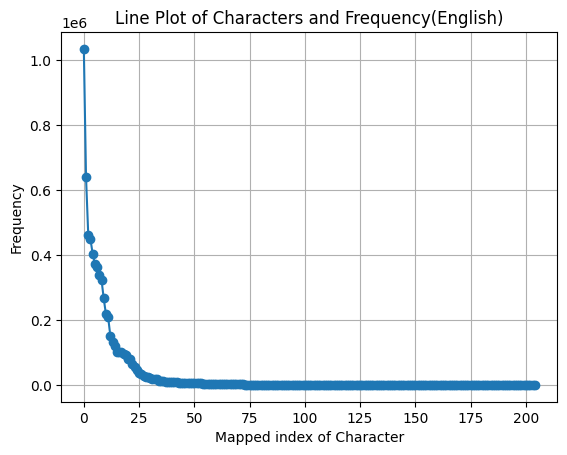

In [8]:
chars = list(en_char_dict.keys())
frequency = list(en_char_dict.values())

char_mapping = {char: i for i, char in enumerate(chars)}
x_values = [char_mapping[char] for char in chars]

plt.plot(x_values, frequency, marker='o', linestyle='-')
plt.xlabel('Mapped index of Character')
plt.ylabel('Frequency')
plt.title('Line Plot of Characters and Frequency(English)')
plt.grid(True)
plt.show()


**Invalid Characters :**<br>
Considering (A-Z) ,(a-z),(0-9) and some punctuations as valid characters.<br>
The invalid characters in the corpus are:

In [9]:
en_valid_chars = [chr(i) for i in range(35, 126)]
en_valid_chars.append(' ')
en_valid_chars.append('\n')
count = 0
print("Invalid characters in the english corpus are : ")
for key,_ in en_char_dict.items():
    if key in en_valid_chars:
        pass
    else:
        print(key ,end=" ")
        count += 1

print(f"\nNumber of invalid characters are: {count}")        

Invalid characters in the english corpus are : 
’ " “ ” ! ‘ … – —  ₹ » • é क ा  ​ ी ह � ° â ­ त न ं म य ´  ् े € ब र ™ ै स ि ❤ ज ो ़ á ñ ó 🙂 ® भ ल ग प   œ ×  व ष । द ¬ ² श ड ½ Â च ― ಡ ？ ï घ ँ ु ई ‏ ओ ‍ £ ́ उ ॐ ण आ ए ऐ थ औ ~ ಮ ಾ ್ ಕ ೊ ಬ ೇ ಿ 😊 ˜ ， ü © „ ध 🙏 🏽 ö ğ 🎧 а ﻿ ू 😀 
Number of invalid characters are: 114


#### Removing the invalid characters ####

In [ ]:
'''new_english_file = "clean_en.txt"

with open(new_english_file, "a",encoding="utf-8") as outfile:
    for x in file1:
      temp = ""
      for y in x:
         if y in en_valid_chars:
            temp += y
         else:
            pass

      outfile.write(temp)
    file1.seek(0)'''

### **Hindi corpus** ###
Iterate through file and add each unique word to **hi_char_dict** dictionary as key and the frequency of the word as value.

In [10]:
for x in file2:
  for character in x:
    if character in hi_char_dict:
      hi_char_dict[str(character)] += 1
    else :
      hi_char_dict[str(character)] = 1
file2.seek(0)

0

Details of the characters, frequency and total number of unique charecters.<br>
The character " " appeared 1178033 (max) times. <br>
Total unique characters are 247.

In [11]:
hi_char_dict = dict(sorted(hi_char_dict.items(), key=lambda item: item[1],reverse=True))
print(hi_char_dict)
print(f"Total number of Unique characters in Hindi corpus {len(hi_char_dict)}")

{' ': 1178033, 'ा': 425957, 'क': 351830, 'र': 331709, 'े': 319649, '्': 219332, 'ी': 216015, 'न': 212603, 'ह': 211351, 'स': 210694, 'ं': 208148, 'ि': 204574, 'म': 176980, 'त': 148201, 'ल': 147030, 'ो': 135865, 'प': 127306, 'य': 122391, '\n': 100000, 'द': 92307, 'व': 87135, 'ै': 85099, 'ज': 80491, 'ब': 76810, 'ग': 72775, 'ु': 68083, '।': 67122, 'ट': 53514, 'ए': 50550, 'श': 45501, 'च': 41341, 'भ': 40870, 'अ': 38305, 'इ': 37248, 'ड': 34756, 'ू': 33848, 'आ': 31198, ',': 29291, 'थ': 28851, 'उ': 26730, 'फ': 26308, 'औ': 25396, 'ख': 24855, 'ध': 24003, '.': 23880, 'ई': 22067, 'ष': 18296, '़': 15114, 'ण': 11441, 'ौ': 10475, 'छ': 9985, 'ॉ': 7559, '-': 7354, 'घ': 6683, '0': 5847, 'ठ': 5558, 'ओ': 5291, '1': 4851, 'झ': 4507, '?': 4296, 'ृ': 3788, '2': 3741, 'ऐ': 3410, 'ढ': 3392, "'": 3303, '(': 3279, ')': 3261, '"': 2834, '\u200d': 2817, '‘': 2668, '5': 2431, 'ड़': 2396, 'ऑ': 2265, '3': 2134, 'a': 2056, ':': 2051, '4': 1996, 'ँ': 1873, 'i': 1670, '9': 1571, 'e': 1462, '6': 1429, '8': 1395, '’': 1378,

In [12]:
# Write word frequency to new file
with open("char_freq_hi.txt", "a",encoding="utf-8") as outfile:
    outfile.write("Char , Frequency\n")
    for key, value in hi_char_dict.items():
      outfile.write(str(key)+" , "+str(value)+"\n")
temp_file = open("char_freq_hi.txt", "r",encoding="utf-8")
print(temp_file.read(100))

Char , Frequency
  , 1178033
ा , 425957
क , 351830
र , 331709
े , 319649
् , 219332
ी , 216015
न , 2


**Plot Chars vs Frequency**

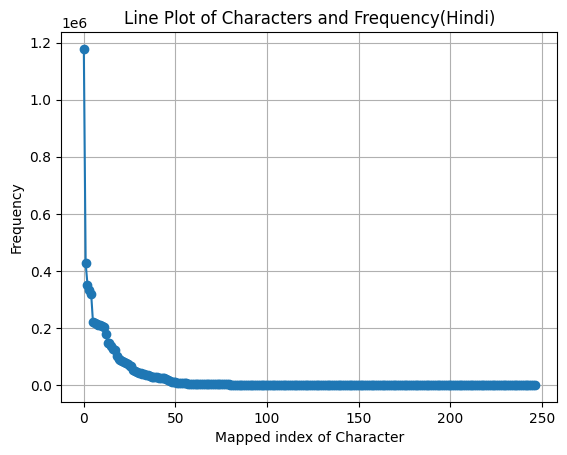

In [13]:
chars = list(hi_char_dict.keys())
frequency = list(hi_char_dict.values())

char_mapping = {char: i for i, char in enumerate(chars)}
x_values = [char_mapping[char] for char in chars]

plt.plot(x_values, frequency, marker='o', linestyle='-')
plt.xlabel('Mapped index of Character')
plt.ylabel('Frequency')
plt.title('Line Plot of Characters and Frequency(Hindi)')
plt.grid(True)
plt.show()

**Invalid characters** : <br>
In the Unicode representation, the valid hindi characters fall in the range **U+0900 to U+097F**. <br> Remaining characters are invalid.

In [14]:
hi_valid_chars = [chr(code_point) for code_point in range(0x0900, 0x097F + 1)]
hi_valid_chars.append(' ')
hi_valid_chars.append('\n')
count = 0
#print(hi_valid_chars)
print('Invalid characters in the Hindi corpus are : ')
for key,_ in hi_char_dict.items():
  if key in hi_valid_chars:
    pass
  else:
    print(key,end=" ")
    count += 1

print(f"\nNumber of invalid characters are: {count}")   

Invalid characters in the Hindi corpus are : 
, . - 0 1 ? 2 ' ( ) " ‍ ‘ 5 3 a : 4 i 9 e 6 8 ’ n ! 7 o r “ S s t P C I h A l B M m d u c G p ” R T / D E N g L O v y K W F H w b ; V k … U J – ​ | f X ‌ x j ` z * + > — Y % Z # » Q › ] [ & @ q • = «  × ï  _ − \ · ° � ² ● < ^   🔊 → ø ′ م ½ ‚ $ ﾥ ó 😢 ‎ í £ ö د ش ق ‬ ₹ μ á Þ 🔷 👍  €  ~ Ó Ñ С ® ص ر 
Number of invalid characters are: 150


#### Removing the Invalid Characters ####

In [ ]:
'''new_hindi_file = "clean_hi.txt"

with open(new_hindi_file, "a",encoding="utf-8") as outfile:
    for x in file2:
      temp = ""
      for y in x:
         if y in hi_valid_chars:
            temp += y
         else:
            pass

      outfile.write(temp)
    file2.seek(0)'''

Open new files

In [15]:
new_file1 = open("clean_en.txt","r",encoding="utf-8")
new_file2 = open("clean_hi.txt","r",encoding="utf-8")

## **Character Level n-grams** ##
Here we will create charecter level N-grams.

First create to dictionaries to store N-grams and their count.

In [16]:
en_n_gram_char_dict = dict()
hi_n_gram_char_dict = dict()

### **English Corpus** ###
For each set of new characters first we directly add them to dictionary with value 1. Whenever the same set of characters comes next time we increment the count by 1.

In [17]:
N = 5
for x in new_file1:
  for i in range(N+1):
    for j in range(len(x)-i):
      key = x[j:j+i]
      if key in en_n_gram_char_dict:
        en_n_gram_char_dict[str(key)] += 1
      else:
        en_n_gram_char_dict[str(key)] = 1

new_file1.seek(0)

0

In [18]:
with open("N_char_grams_en.txt", "a", encoding="utf-8") as outfile:
    for n in range(1,N+1):
       for key, value in en_n_gram_char_dict.items():
        if(len(key)==n):
          outfile.write(str(key)+"      "+str(value)+"\n")

temp_file =  open("N_char_grams_en.txt", "r", encoding="utf-8") 
print(temp_file.read(150))

T      28482
w      79372
o      363267
       1034882
a      462717
m      121129
b      63691
u      131600
l      208934
n      372957
c      15058


In [19]:
len(en_n_gram_char_dict)

490346

### **Hindi corpus** ###

Repeat the same process for Hindi corpus.

In [20]:
N = 5
for x in new_file2:
  for i in range(N+1):
    for j in range(len(x)-i):
      key = x[j:j+i]
      if key in hi_n_gram_char_dict:
        hi_n_gram_char_dict[str(key)] += 1
      else:
        hi_n_gram_char_dict[str(key)] = 1

new_file2.seek(0)

0

In [21]:
with open("N_char_grams_hi.txt", "a", encoding="utf-8") as outfile:
    for n in range(1,N+1):
       for key, value in hi_n_gram_char_dict.items():
        if(len(key)==n):
          outfile.write(str(key)+"      "+str(value)+"\n")

temp_file =  open("N_char_grams_hi.txt", "r", encoding="utf-8") 
print(temp_file.read(150))        

इ      37248
स      210694
क      351830
े      319649
       1178033
ल      147030
ि      204574
ए      50550
प      127306
्      219332
र      3317


In [22]:
len(hi_n_gram_char_dict)

547313

# **Operations on Words** #
In this section we will explore all operations on words.

## **Calculate Word frequency** ##
We will store words and their frequency in a dictionary.

### **English Corpus** ###

In [23]:
en_word_dict = dict()

In [24]:
for x in new_file1:
  words = x.split(' ')
  for word in words:
    if word in en_word_dict:
      en_word_dict[str(word)] += 1
    else :
      en_word_dict[str(word)] = 1
new_file1.seek(0)

0

In [25]:
en_word_dict = dict(sorted(en_word_dict.items(), key=lambda item: item[1],reverse=True))
#print(en_dict)
print(f"Total number of Unique words in English corpus {len(en_word_dict)}")

Total number of Unique words in English corpus 80395


**Plot of Word vs Frequency**

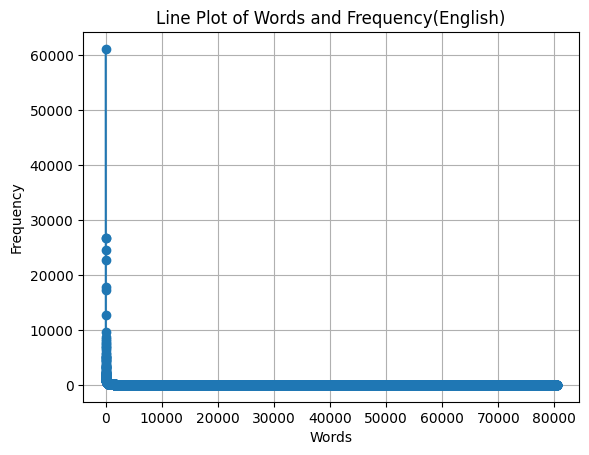

In [26]:
words = list(en_word_dict.keys())
frequency = list(en_word_dict.values())

word_mapping = {word: i for i, word in enumerate(words)}
x_values = [word_mapping[word] for word in words]

plt.plot(x_values, frequency, marker='o', linestyle='-')
#plt.xticks(words,frequency)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Line Plot of Words and Frequency(English)')
plt.grid(True)
plt.show()

In [27]:
# Write word frequency to new file
with open("word_freq_en.txt", "a" ,encoding="utf-8") as outfile:
    outfile.write("Word , Frequency\n")
    for key, value in en_word_dict.items():
      outfile.write(str(key)+" , "+str(value)+"\n")

### **Hindi Corpus** ###

In [28]:
hi_word_dict = dict()

In [29]:
for x in new_file2:
  words = x.split()
  for word in words:
    if word in hi_word_dict:
      hi_word_dict[str(word)] += 1
    else :
      hi_word_dict[str(word)] = 1
new_file2.seek(0)

0

In [31]:
hi_word_dict = dict(sorted(hi_word_dict.items(), key=lambda item: item[1],reverse=True))
#print(hi_dict)
print(f"Total number of Unique words in Hindi corpus {len(hi_word_dict)}")

Total number of Unique words in Hindi corpus 50605


In [32]:
# Write word frequency to new file
with open("word_freq_hi.txt", "a", encoding="utf-8") as outfile:
    outfile.write("Word , Frequency\n")
    for key, value in hi_word_dict.items():
      outfile.write(str(key)+" , "+str(value)+"\n")

**Plot Word vs Frequency**

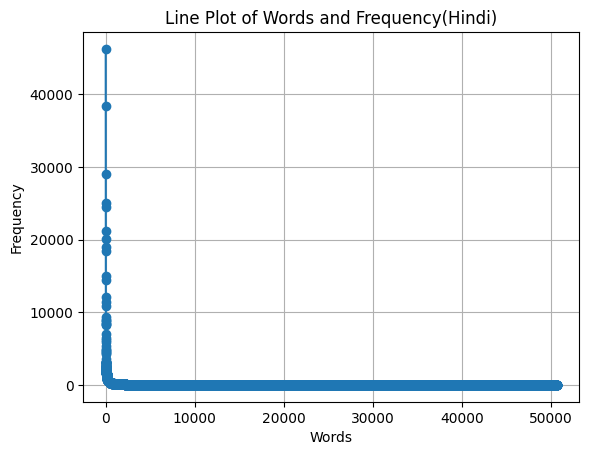

In [33]:
words = list(hi_word_dict.keys())
frequency = list(hi_word_dict.values())

word_mapping = {word: i for i, word in enumerate(words)}
x_values = [word_mapping[word] for word in words]

plt.plot(x_values, frequency, marker='o', linestyle='-')
#plt.xticks(words,frequency)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Line Plot of Words and Frequency(Hindi)')
plt.grid(True)
plt.show()

## **Coverage in corpus** ##
Coverage is calculated by dividing word frequency with total number of words in the corpus.<br>

So first we need to calculate total number of words.

### **English Corpus** ###

In [34]:
total_words_en = 0
for key, value in en_word_dict.items():
  total_words_en += value

In [35]:
print(f"Number of words in English corpus {total_words_en}")

Number of words in English corpus 1134882


In [36]:
percentage_en = dict()

In [37]:
for key, value in en_word_dict.items():
  percentage_en[str(key)] = 100*(value/total_words_en)
#print(percentage_en)
count = 0
for value in percentage_en.values():
    print(value)
    count += 1
    if count == 10:
        break

5.383467179847773
2.3612146461041763
2.3518744680063657
2.1648065613869987
2.0061997634996414
1.56412737183249
1.5155760687014157
1.1203807972987498
0.8499562069008055
0.7604314809821637


In [38]:
# Write word frequency to new file
with open("word_coverage_en.txt", "a") as outfile:
    outfile.write("Word , Coverage\n")
    for key, value in percentage_en.items():
      outfile.write(str(key)+" , "+str(value)+" %\n")

### **Hindi Corpus** ###

In [39]:
total_words_hi = 0
for key, value in hi_word_dict.items():
  total_words_hi += value

In [40]:
print(f"Number of words in Hindi corpus {total_words_hi}")

Number of words in Hindi corpus 1257556


In [41]:
percentage_hi = dict()

In [42]:
for key, value in hi_word_dict.items():
  percentage_hi[str(key)] = 100*(value/total_words_hi)
#print(percentage_hi)
count = 0
for value in percentage_hi.values():
    print(value)
    count += 1
    if count == 10:
        break

3.6753830445721705
3.0461466527136762
2.3121833143017088
1.9950602597419123
1.9412256790154871
1.683344519051239
1.5938852822458802
1.5042670067973116
1.4615651310955535
1.1865873169862813


In [43]:
# Write word frequency to new file
with open("word_coverage_hi.txt", "a" , encoding="utf-8") as outfile:
    outfile.write("Word , Coverage\n")
    for key, value in percentage_hi.items():
      outfile.write(str(key)+" , "+str(value)+" %\n")

## **Word level n-grams** ##
Here we will create word N-grams. 

### **English Corpus** ###

In [44]:
en_n_gram_word_dict = dict()

In [45]:
new_file1.seek(0)

0

In [46]:
N = 6
for x in new_file1:
  words = x.split()
  for i in range(N):
    for j in range(N-i):
      key = words[j:j+i]
      if str(key) in en_n_gram_word_dict:
        en_n_gram_word_dict[str(key)] += 1
      else:
        en_n_gram_word_dict[str(key)] = 1

new_file1.seek(0)

0

In [47]:
len(en_n_gram_word_dict)

655671

In [48]:
keys_list = list(en_n_gram_word_dict.keys())

tenth_key = keys_list[:11]
print(tenth_key)

['[]', "['Two']", "['ambulances']", "['will']", "['be']", "['provided']", "['Two', 'ambulances']", "['ambulances', 'will']", "['will', 'be']", "['be', 'provided']", "['Two', 'ambulances', 'will']"]


In [49]:
with open("n_word_grams_en.txt", "a",encoding="utf-8") as outfile:
  outfile.write("n-gram_word                   Frequency\n")
  for key, value in en_n_gram_word_dict.items():
    outfile.write(str(key)+"      "+str(value)+"\n")

### **Hindi Corpus** ###

In [50]:
hi_n_gram_word_dict = dict()

In [51]:
N = 6
for x in new_file2:
  words = x.split()
  for i in range(N):
    for j in range(N-i):
      key = words[j:j+i]
      if str(key) in hi_n_gram_word_dict:
        hi_n_gram_word_dict[str(key)] += 1
      else:
        hi_n_gram_word_dict[str(key)] = 1

new_file2.seek(0)

0

In [52]:
len(hi_n_gram_word_dict)

695503

In [53]:
N = 6
with open("n_word_grams_hi.txt", "a",encoding="utf-8") as outfile:
    outfile.write("n-gram_word                   Frequency\n")
    for n in range(1,N+1):
       for key, value in hi_n_gram_word_dict.items():
        if(len(key)==n):
          outfile.write(str(key)+"      "+str(value)+"\n")

## **Word length analysis** ##

### **English Corpus** ###

In [54]:
def calculate_word_lengths(corpus_file):
    with open(corpus_file, 'r', encoding='utf-8') as file:
        words = re.findall(r'\b\w+\b', file.read())

    word_lengths = [len(word) for word in words]

    min_length = min(word_lengths)
    max_length = max(word_lengths)
    avg_length = statistics.mean(word_lengths)
    std_dev = statistics.stdev(word_lengths)

    return word_lengths, min_length, max_length, avg_length, std_dev

corpus_file = "clean_en.txt"
word_lengths, min_length, max_length, avg_length, std_dev = calculate_word_lengths(corpus_file)

print("In English corpus")
print("Minimum word length:", min_length)
print("Maximum word length:", max_length)
print("Average word length:", avg_length)
print("Standard deviation of word lengths:", std_dev)

In English corpus
Minimum word length: 1
Maximum word length: 25
Average word length: 4.709944153388767
Standard deviation of word lengths: 2.490332611959222


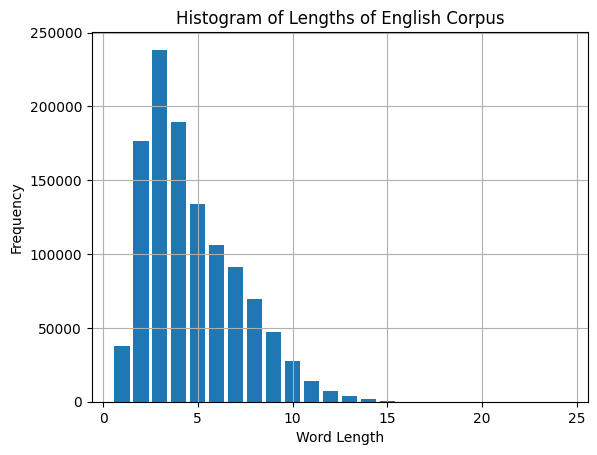

In [55]:
plt.hist(word_lengths, bins=range(min(word_lengths), max(word_lengths) + 1), align='left', rwidth=0.8)
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Histogram of Lengths of English Corpus')
plt.grid(True)
plt.show()

### **Hindi Corpus** ###

In [56]:
corpus_file = "clean_hi.txt"
word_lengths, min_length, max_length, avg_length, std_dev = calculate_word_lengths(corpus_file)

print("In Hindi corpus")
print("Minimum word length:", min_length)
print("Maximum word length:", max_length)
print("Average word length:", avg_length)
print("Standard deviation of word lengths:", std_dev)

In Hindi corpus
Minimum word length: 1
Maximum word length: 11
Average word length: 1.3403414937706934
Standard deviation of word lengths: 0.6110286246416378


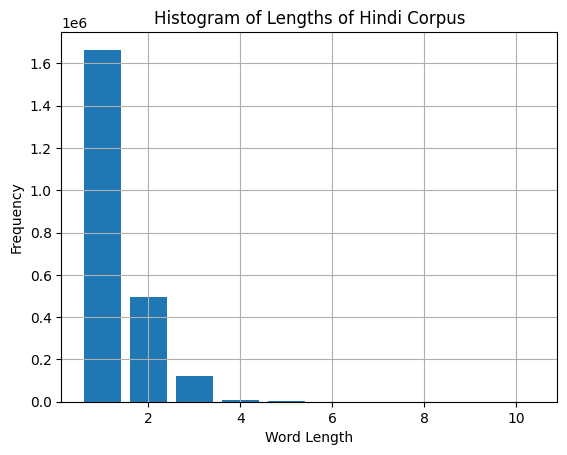

In [57]:
plt.hist(word_lengths, bins=range(min(word_lengths), max(word_lengths) + 1), align='left', rwidth=0.8)
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Histogram of Lengths of Hindi Corpus')
plt.grid(True)
plt.show()

## **Sentence Length Analysis** ##

### **Based on number of characters** ###

#### **English Corpus** ####

In [58]:
list_char_en = []

In [59]:
new_file1 = open('clean_en.txt', 'r', encoding='utf-8')
for x in new_file1:
  list_char_en.append(len(x))

min_sen_len_en = min(list_char_en)
max_sen_len_en = max(list_char_en)
avg_sen_len_en = sum(list_char_en)/len(list_char_en)
std_dev_sen_len_en = statistics.stdev(list_char_en)

new_file1.seek(0)

0

In [60]:
print("In English corpus")
print(f"Minimum length of sentence = {min_sen_len_en}")
print(f"Maximum length of sentence = {max_sen_len_en}")
print(f"Average length of sentence = {avg_sen_len_en}")
print(f"Standard deviation of sentence length = {std_dev_sen_len_en}")

In English corpus
Minimum length of sentence = 2
Maximum length of sentence = 984
Average length of sentence = 67.08741
Standard deviation of sentence length = 48.578129521818546


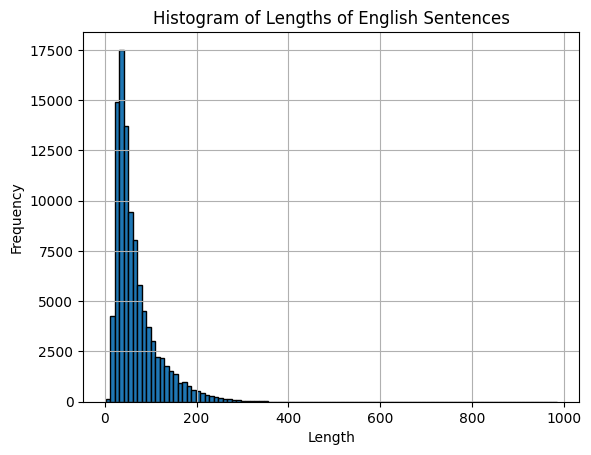

In [61]:
plt.hist(list_char_en, bins=100, edgecolor='black')
plt.title('Histogram of Lengths of English Sentences')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### **Hindi Corpus** ####

In [62]:
list_char_hi = []

In [63]:
file2 = open('clean_hi.txt', 'r', encoding='utf-8')
for x in file2:
  list_char_hi.append(len(x))

min_sen_len_hi = min(list_char_hi)
max_sen_len_hi = max(list_char_hi)
avg_sen_len_hi = sum(list_char_hi)/len(list_char_hi)
std_dev_sen_len_hi = statistics.stdev(list_char_hi)

file2.seek(0)

0

In [64]:
print("In Hindi corpus")
print(f"Minimum length of sentence = {min_sen_len_hi}")
print(f"Maximum length of sentence = {max_sen_len_hi}")
print(f"Average length of sentence = {avg_sen_len_hi}")
print(f"Standard deviation of sentence length = {std_dev_sen_len_hi}")

In Hindi corpus
Minimum length of sentence = 5
Maximum length of sentence = 610
Average length of sentence = 63.78979
Standard deviation of sentence length = 44.704616392305255


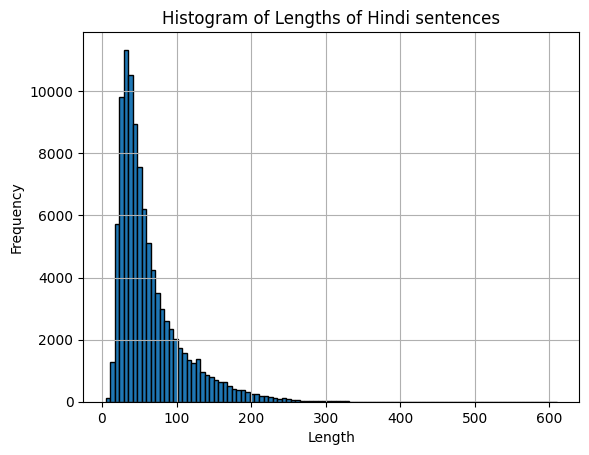

In [65]:
#Histogram
plt.hist(list_char_hi, bins=100, edgecolor='black')
plt.title('Histogram of Lengths of Hindi sentences')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### **Based on Number of words** ###

#### **English Corpus** ####

In [66]:
list_word_en = []

In [67]:
for x in new_file1:
  temp_list = x.split()
  list_word_en.append(len(temp_list))

min_num_words_en = min(list_word_en)
max_num_words_en = max(list_word_en)
avg_num_words_en = sum(list_word_en)/len(list_word_en)
std_dev_sen_num_words_en = statistics.stdev(list_word_en)

new_file1.seek(0)

0

In [68]:
print("In English corpus")
print(f"Minimum number of words in sentence = {min_num_words_en}")
print(f"Maximum number of words in  sentence= {max_num_words_en}")
print(f"Average number of words in sentence = {avg_num_words_en}")
print(f"Standard deviation of number of words in sentence = {std_dev_sen_num_words_en}")

In English corpus
Minimum number of words in sentence = 0
Maximum number of words in  sentence= 122
Average number of words in sentence = 11.34191
Standard deviation of number of words in sentence = 7.626845300620198


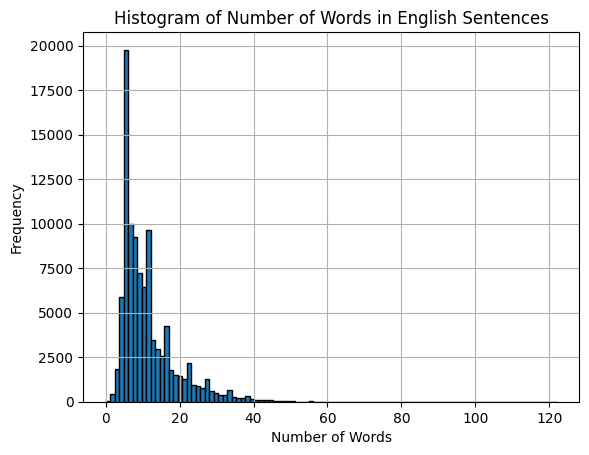

In [69]:
#Histogram
plt.hist(list_word_en, bins=100, edgecolor='black')
plt.title('Histogram of Number of Words in English Sentences')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### **Hindi Corpus** ####

In [70]:
list_word_hi = []

In [71]:
for x in new_file2:
  temp_list = x.split()
  list_word_hi.append(len(temp_list))

min_num_words_hi = min(list_word_hi)
max_num_words_hi = max(list_word_hi)
avg_num_words_hi = sum(list_word_hi)/len(list_word_hi)
std_dev_sen_num_words_hi = statistics.stdev(list_word_hi)

new_file2.seek(0)

0

In [72]:
print("In Hindi corpus")
print(f"Minimum number of words in sentence = {min_num_words_hi}")
print(f"Maximum number of words in  sentence= {max_num_words_hi}")
print(f"Average number of words in sentence = {avg_num_words_hi}")
print(f"Standard deviation of number of words in sentence = {std_dev_sen_num_words_hi}")

In Hindi corpus
Minimum number of words in sentence = 1
Maximum number of words in  sentence= 109
Average number of words in sentence = 12.57556
Standard deviation of number of words in sentence = 8.251869583307544


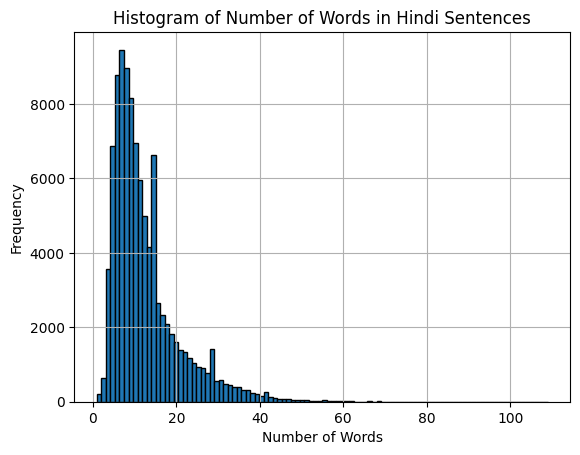

In [73]:
#Histogram
plt.hist(list_word_hi, bins=100, edgecolor='black')
plt.title('Histogram of Number of Words in Hindi Sentences')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## **Word Cooccurance Matrix** ##
Add the counts to a dictionary , later write it to a file.

In [74]:
#stored in a dictionary where (word_english,word_hindi) is the key and count is the value
word_cooccurance_matrix = dict()

In [75]:
for en_x,hi_x in zip(new_file1,new_file2):
  english_tokens = en_x.split()
  hindi_tokens = hi_x.split()
  for english_word in english_tokens:
    for hindi_word in hindi_tokens:
      key = english_word + "-" + hindi_word
      if key in word_cooccurance_matrix :
        word_cooccurance_matrix[str(key)] += 1
      else:
        word_cooccurance_matrix[str(key)] = 1
new_file1.seek(0)
new_file2.seek(0)

0

In [76]:
word_cooccurance_matrix = dict(sorted(word_cooccurance_matrix.items(), key=lambda item: item[1],reverse=True))

In [77]:
#print(word_cooccurance_matrix)
with open("word_cooccurance.txt", "a", encoding="utf-8") as outfile:
    outfile.write("English-Hindi , Count\n")
    for key, value in word_cooccurance_matrix.items():
      outfile.write(str(key)+" , "+str(value)+"\n")
    
temp_file = open("word_cooccurance.txt", "r", encoding = "utf-8")
print(temp_file.read(250))

English-Hindi , Count
the-के , 56121
the-में , 38073
the-की , 31174
of-के , 28997
and-और , 26343
in-में , 24752
and-के , 24668
the-और , 22731
the-को , 22440
the-ने , 22161
to-के , 21519
in-के , 18104
the-से , 18035
the-है , 17157
and-में , 16488
of-क


In [78]:
print(len(word_cooccurance_matrix.items()))

6597857
